In [6]:
# This script is used to process the data from a polarization filter calibration experiment. It assumes the data is stored in a .sif file with 2D images for each angle of the polarization filter.

import pickle
from pathlib import Path

import sif_parser
import numpy as np
import matplotlib.pyplot as plt

base_loc = r"D:\experiment 24 mrt 2026"
# f_pickle = Path(rf"{base_loc}\labctl\S1_044_calibr_80to140_0.4000s_idx.pkl")
f_pickle = Path(rf"{base_loc}\Raman_timing_idx.pkl")
f_data = Path(rf"{base_loc}\Raman_timing_results.sif")  # Replace with path of the .sif file
has_background = False

# Load pickle file
info = pickle.load(open(f_pickle, "rb"))
data, img_info = sif_parser.np_open(f_data)
image_size = img_info['size']

def get_data(data, info, index):
    # Get the keys for the signal and background indices
    # Get the indices for the signal and background
    sig_ind = info['indices'][0][index][0]
    bg_ind = info['indices'][0][index][1]

    if len(bg_ind) != 0:
        # Get the data for the signal and background
        sig_data = data[sig_ind, :, :]
        bg_data = data[bg_ind, :, :]

        sig_data = np.squeeze(sig_data)
        bg_data_avg = np.squeeze(np.mean(bg_data, axis=0))
        return sig_data - bg_data_avg
    else:
        sig_data = data[sig_ind, :, :]
        sig_data = np.squeeze(sig_data)
        return sig_data

# Get the used angles from the pickle info
if "variable" in info:
    variable = info[info["variable"]]
    print(info["variable"])
else:
    raise ValueError("No timesweep information found in pickle file.")

# Extract the data from the .sif file
n_frames = info["N_frames"][0]
for n in info["N_frames"][1:]:
    if n != n_frames:
        raise ValueError("Number of frames varies over measurements")

indexes = [0, 1024]

sig = np.zeros((len(variable), n_frames, image_size[1], indexes[1] - indexes[0]))

for i in range(len(variable)):
    sigi = get_data(data, info, i)
    sig[i] = sigi[:, :, slice(*indexes)]
sigs = np.mean(sig, axis=2)
sigs_avg = np.max(sigs, axis=2)

t


(4.6e-07, 4.7e-07)

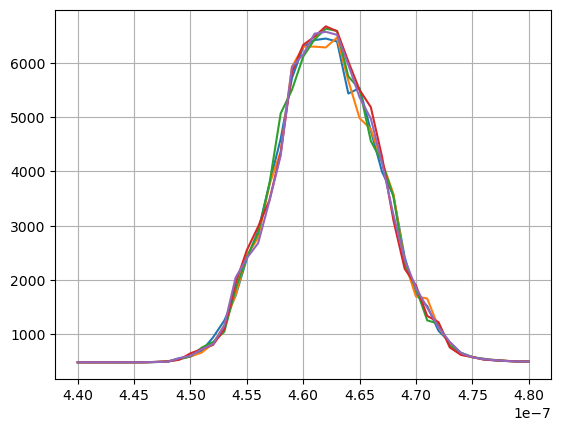

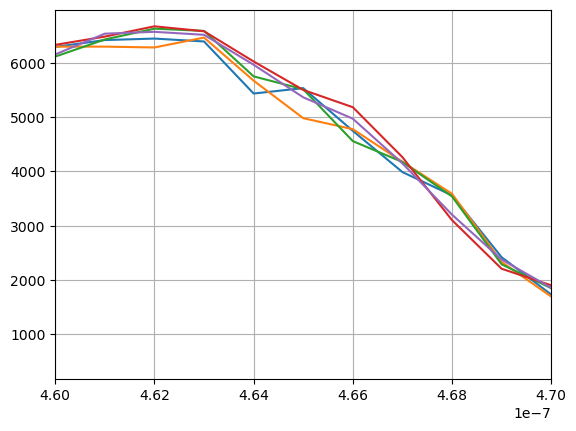

In [10]:
fig, ax = plt.subplots()
ax.plot(variable, sigs_avg)
ax.grid(True)

fig, ax = plt.subplots()
ax.plot(variable, sigs_avg)
ax.grid(True)
ax.set_xlim(4.6e-7, 4.7e-7)
